In [10]:
#=============== MỨC 2 - MACHINE LEARNING REGRESSION ==============
# CELL 1: Cài đặt thư viện nếu chưa có
!pip install xgboost openpyxl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Sklearn imports
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, classification_report

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

import warnings
warnings.filterwarnings('ignore')

# 1. ĐỌC DỮ LIỆU TỪ FILE EXCEL
# Khai báo tên file Excel chính xác
file_path_colab = '/content/Transportation & Logistics Tracking Dataset.xlsx'
file_path_local = 'Transportation & Logistics Tracking Dataset.xlsx'

# Lựa chọn đường dẫn phù hợp
if os.path.exists(file_path_colab):
    file_path = file_path_colab
else:
    file_path = file_path_local

try:
    # Dùng read_excel và chỉ định rõ lấy dữ liệu từ sheet 'Primary Data'
    df = pd.read_excel(file_path, sheet_name='Primary Data')
    print("🎉 ĐỌC DỮ LIỆU THÀNH CÔNG!")
    print("Kích thước dữ liệu gốc:", df.shape)
except FileNotFoundError:
    print("❌ LỖI: MÁY VẪN CHƯA TÌM THẤY FILE EXCEL!")
    print("-" * 50)
    print("👉 NẾU BẠN DÙNG GOOGLE COLAB, HÃY LÀM CÁCH NÀY ĐỂ TẢI FILE LÊN:")
    print("Tạo một ô code mới (Add Code), copy dán đoạn lệnh sau vào và chạy:")
    print("from google.colab import files")
    print("uploaded = files.upload()")
    print("-> Sau đó bấm nút 'Choose Files' hiện ra để chọn file Transportation & Logistics Tracking Dataset.xlsx từ máy tính của bạn.")
    print("-> Khi tải xong 100%, quay lại chạy ô code này là được!")
except ValueError as e:
    print(f"❌ LỖI SHEET: Không tìm thấy sheet 'Primary Data' trong file Excel. Vui lòng kiểm tra lại tên sheet. Lỗi chi tiết: {e}")

🎉 ĐỌC DỮ LIỆU THÀNH CÔNG!
Kích thước dữ liệu gốc: (3585, 28)


In [12]:
# CELL 2:TIỀN XỬ LÝ DỮ LIỆU (DATA PREPROCESSING)
# 1. Xử lý giá trị thiếu (Missing Values)
# Thay thế các giá trị 'NULL', 'NA' dạng chuỗi thành np.nan thực sự
df.replace(['NULL', 'NA', 'Null', 'na'], np.nan, inplace=True)

# Điền giá trị thiếu cho 'Minimum Kms To Be Covered In A Day' bằng giá trị trung bình
df['Minimum Kms To Be Covered In A Day'] = pd.to_numeric(df['Minimum Kms To Be Covered In A Day'], errors='coerce')
df['Minimum Kms To Be Covered In A Day'].fillna(df['Minimum Kms To Be Covered In A Day'].mean(), inplace=True)

# 2. Tạo biến Mục tiêu (Target Variable)
# Dự đoán Delay -> Ontime = 'No' sẽ là 1 (Có nguy cơ trễ), 'Yes' là 0 (Đúng hạn)
df['Target_Delay'] = df['Ontime'].apply(lambda x: 1 if str(x).strip().lower() == 'no' else 0)

# 3. Xử lý dữ liệu Thời gian (Datetime)
datetime_cols = ['Booking Date', 'Trip Start Date', 'Planned ETA']
for col in datetime_cols:
    df[col] = pd.to_datetime(df[col], errors='coerce')

# Feature Engineering: Lấy ra các đặc trưng thời gian có thể ảnh hưởng đến delay
df['Booking_Month'] = df['Booking Date'].dt.month
df['Booking_DayOfWeek'] = df['Booking Date'].dt.dayofweek # 0: Thứ 2, 6: Chủ nhật
df['Planned_ETA_Hour'] = df['Planned ETA'].dt.hour

# Tạo cột Trip_Duration_Planned (Số ngày dự kiến vận chuyển)
df['Trip_Duration_Planned_Hours'] = (df['Planned ETA'] - df['Trip Start Date']).dt.total_seconds() / 3600
# Xử lý các giá trị âm hoặc NaN do lỗi nhập liệu
df['Trip_Duration_Planned_Hours'] = df['Trip_Duration_Planned_Hours'].apply(lambda x: x if x > 0 else df['Trip_Duration_Planned_Hours'].median())
df['Trip_Duration_Planned_Hours'].fillna(df['Trip_Duration_Planned_Hours'].median(), inplace=True)


In [14]:
#CELL 3: LỰA CHỌN ĐẶC TRƯNG & MÃ HÓA (FEATURE SELECTION & ENCODING)
# 1. Lựa chọn đặc trưng (Features)
selected_features = [
    'Transportation Distance (KM)', 'Shipment Type', 'Supplier Name', 'Vehicle Type',
    'Gps Provider', 'Customer Name', 'Minimum Kms To Be Covered In A Day',
    'Booking_Month', 'Booking_DayOfWeek', 'Planned_ETA_Hour', 'Trip_Duration_Planned_Hours'
]

X = df[selected_features].copy()
y = df['Target_Delay']

# Ép kiểu distance về dạng số
X['Transportation Distance (KM)'] = pd.to_numeric(X['Transportation Distance (KM)'], errors='coerce')
X['Transportation Distance (KM)'].fillna(X['Transportation Distance (KM)'].median(), inplace=True)

# 2. Mã hóa biến phân loại (Encoding Categorical Variables)
cat_cols = ['Shipment Type', 'Supplier Name', 'Vehicle Type', 'Gps Provider', 'Customer Name']

# Sử dụng LabelEncoder để biến các chuỗi văn bản thành số học (0, 1, 2...)
encoders = {}
for col in cat_cols:
    # Xử lý missing dạng text
    X[col] = X[col].fillna('Unknown').astype(str)

    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    encoders[col] = le

In [16]:
# CELL 4: CHIA TẬP DỮ LIỆU & CHUẨN HÓA (TRAIN/TEST SPLIT & SCALING)
# 1. Train / Test Split (Chia 80% huấn luyện, 20% kiểm thử)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print("Số lượng tập Train:", X_train.shape[0])
print("Số lượng tập Test:", X_test.shape[0])

# 2. Data Scaling (Chuẩn hóa dữ liệu số học về cùng một thang đo)
num_cols = ['Transportation Distance (KM)', 'Minimum Kms To Be Covered In A Day', 'Trip_Duration_Planned_Hours']

scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])


Số lượng tập Train: 2868
Số lượng tập Test: 717


In [18]:
# CELL 5: XÂY DỰNG & ĐÁNH GIÁ MÔ HÌNH (MODELING & EVALUATION)
# Khởi tạo các mô hình
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
}

# Lưu trữ kết quả
results = []

print("="*50)
print("KẾT QUẢ ĐÁNH GIÁ CÁC MÔ HÌNH:")
print("="*50)

for name, model in models.items():
    # 1. Huấn luyện mô hình
    model.fit(X_train, y_train)

    # 2. Dự đoán trên tập Test
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1] # Lấy xác suất của class 1 (Delay)

    # 3. Tính toán các độ đo (Metrics)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    roc_auc = roc_auc_score(y_test, y_pred_proba)

    results.append({
        "Model": name, "Accuracy": acc, "Precision": prec,
        "Recall": rec, "F1-Score": f1, "ROC-AUC": roc_auc
    })

    # In báo cáo chi tiết
    print(f"\n--- {name} ---")
    print(classification_report(y_test, y_pred, zero_division=0))
    print(f"ROC-AUC Score: {roc_auc:.4f}")

# Tạo bảng tổng hợp kết quả
results_df = pd.DataFrame(results).sort_values(by="ROC-AUC", ascending=False)
display(results_df)



KẾT QUẢ ĐÁNH GIÁ CÁC MÔ HÌNH:

--- Logistic Regression ---
              precision    recall  f1-score   support

           0       0.86      0.74      0.79       276
           1       0.85      0.93      0.89       441

    accuracy                           0.85       717
   macro avg       0.86      0.83      0.84       717
weighted avg       0.85      0.85      0.85       717

ROC-AUC Score: 0.9181

--- Decision Tree ---
              precision    recall  f1-score   support

           0       0.84      0.85      0.84       276
           1       0.91      0.90      0.90       441

    accuracy                           0.88       717
   macro avg       0.87      0.87      0.87       717
weighted avg       0.88      0.88      0.88       717

ROC-AUC Score: 0.8730

--- Random Forest ---
              precision    recall  f1-score   support

           0       0.90      0.84      0.87       276
           1       0.90      0.94      0.92       441

    accuracy                     

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
3,XGBoost,0.903766,0.907895,0.938776,0.923077,0.961032
2,Random Forest,0.900976,0.903930,0.938776,0.921023,0.955951
0,Logistic Regression,0.853556,0.848548,0.927438,0.886241,0.918104
1,Decision Tree,0.878661,0.905963,0.895692,0.900798,0.873004


In [19]:
# CELL 6: TỐI ƯU HÓA SIÊU THAM SỐ (HYPERPARAMETER TUNING)
print("\nBắt đầu tinh chỉnh tham số cho XGBoost...")

# Định nghĩa các tham số cần thử nghiệm
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2]
}

xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)

# Chạy Cross-Validation 5 folds
grid_search = GridSearchCV(estimator=xgb, param_grid=param_grid,
                           cv=5, scoring='roc_auc', n_jobs=-1, verbose=1)

grid_search.fit(X_train, y_train)

print("Tham số tối ưu nhất:", grid_search.best_params_)

# Đánh giá lại mô hình tốt nhất
best_xgb = grid_search.best_estimator_
y_pred_best = best_xgb.predict(X_test)
y_pred_proba_best = best_xgb.predict_proba(X_test)[:, 1]

print("\n--- XG-Boost (Tuned) ---")
print(classification_report(y_test, y_pred_best))
print(f"ROC-AUC (Tuned): {roc_auc_score(y_test, y_pred_proba_best):.4f}")




Bắt đầu tinh chỉnh tham số cho XGBoost...
Fitting 5 folds for each of 18 candidates, totalling 90 fits
Tham số tối ưu nhất: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 100}

--- XG-Boost (Tuned) ---
              precision    recall  f1-score   support

           0       0.91      0.86      0.88       276
           1       0.91      0.95      0.93       441

    accuracy                           0.91       717
   macro avg       0.91      0.90      0.90       717
weighted avg       0.91      0.91      0.91       717

ROC-AUC (Tuned): 0.9627


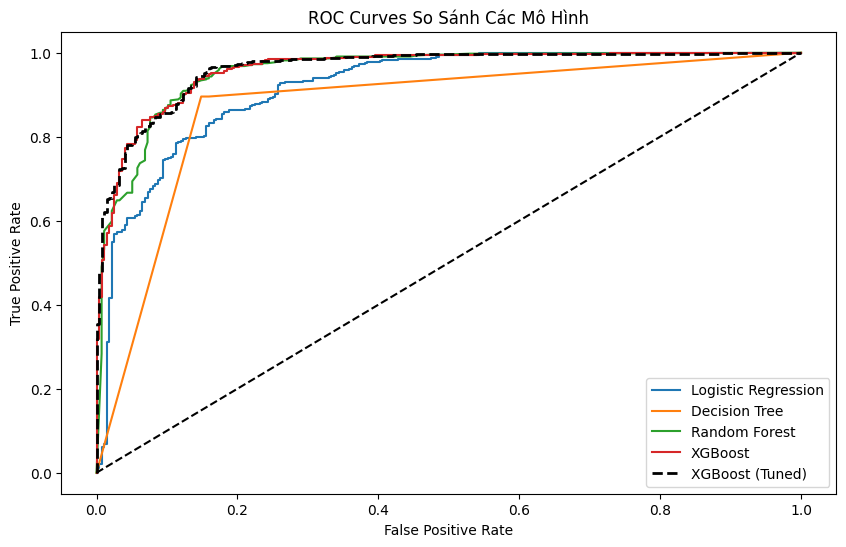

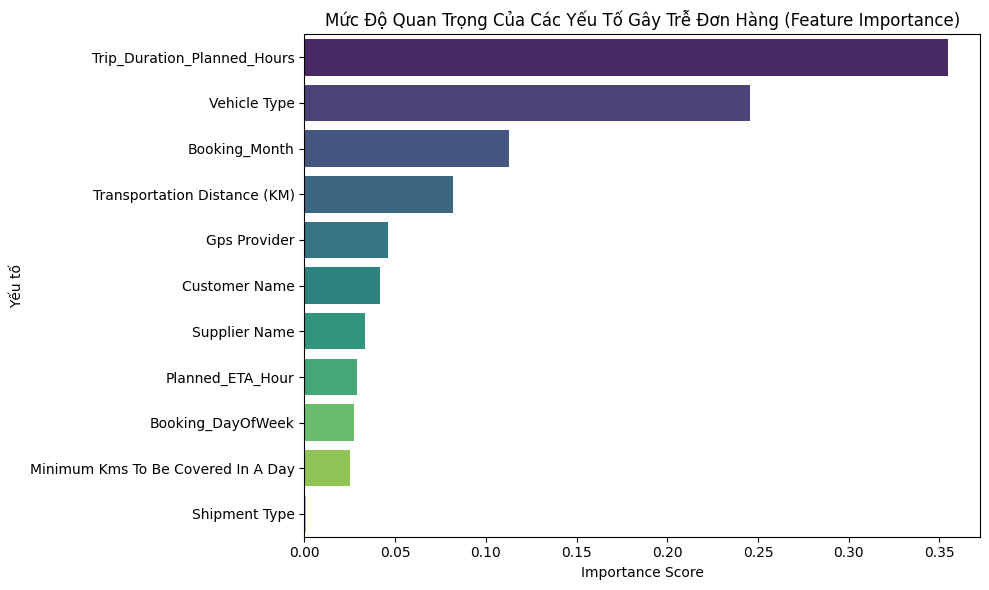

In [20]:
# CELL 7: VẼ ĐƯỜNG CONG ROC VÀ TÌM NGUYÊN NHÂN DELAY (FEATURE IMPORTANCE)
# 1. VẼ ĐƯỜNG CONG ROC-AUC SO SÁNH
plt.figure(figsize=(10, 6))

for name, model in models.items():
    fpr, tpr, _ = roc_curve(y_test, model.predict_proba(X_test)[:, 1])
    plt.plot(fpr, tpr, label=f"{name}")

# Thêm đường của mô hình đã Tuned
fpr_tuned, tpr_tuned, _ = roc_curve(y_test, y_pred_proba_best)
plt.plot(fpr_tuned, tpr_tuned, label="XGBoost (Tuned)", linestyle='--', color='black', linewidth=2)

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves So Sánh Các Mô Hình')
plt.legend()
plt.show()

# 2. PHÂN TÍCH TẦM QUAN TRỌNG CỦA CÁC YẾU TỐ (FEATURE IMPORTANCE)
importance = best_xgb.feature_importances_
feature_names = X_train.columns

feature_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importance})
feature_imp_df = feature_imp_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_imp_df, palette='viridis')
plt.title('Mức Độ Quan Trọng Của Các Yếu Tố Gây Trễ Đơn Hàng (Feature Importance)')
plt.xlabel('Importance Score')
plt.ylabel('Yếu tố')
plt.tight_layout()
plt.show()

### PHÂN TÍCH NGUYÊN NHÂN DELAY & ĐỀ XUẤT CHIẾN LƯỢC TỐI ƯU HÓA QUY TRÌNH
*(Dựa trên kết quả mô hình XGBoost - Mức 2)*

Qua biểu đồ phân tích mức độ quan trọng của các đặc trưng (Feature Importance), mô hình Machine Learning đã chỉ ra 4 yếu tố có tầm ảnh hưởng lớn nhất đến tỷ lệ giao hàng trễ (Delayed Shipment). Từ kết quả học máy này, chúng ta có thể rút ra các chẩn đoán nghiệp vụ và hướng giải quyết triệt để cho doanh nghiệp như sau:

**1. Thời gian vận chuyển dự kiến (`Trip_Duration_Planned_Hours`) - Trọng số cao nhất:**
* **Chẩn đoán:** Đây là nguyên nhân gốc rễ dẫn đến hệ thống báo trễ. Việc bộ phận lên kế hoạch (Planning) thiết lập thời gian đến dự kiến (Planned ETA) thiếu tính thực tế, quá sát sao hoặc không cộng thêm "thời gian đệm" (buffer time) cho các rủi ro dọc đường (như kẹt xe, làm thủ tục bốc dỡ) đã tạo ra áp lực phi thực tế, dẫn đến hệ quả là tài xế không thể đáp ứng đúng hạn.
* **Đề xuất chiến lược:** Doanh nghiệp cần cập nhật lại hệ thống thuật toán tính toán ETA. Thay vì tính bằng công thức tĩnh cơ bản (Quãng đường / Vận tốc trung bình), bộ phận Vận hành cần tích hợp chính mô hình Machine Learning này để dự báo lại một `Planned ETA` linh hoạt và chính xác hơn cho từng điều kiện thực tế.

**2. Loại phương tiện vận chuyển (`Vehicle Type`) - Mức độ ảnh hưởng thứ 2:**
* **Chẩn đoán:** Loại phương tiện quyết định trực tiếp đến tốc độ và khả năng di chuyển trên các địa hình/tuyến đường khác nhau. Việc biến này đứng thứ 2 chứng tỏ công ty đang điều phối sai loại xe cho một số tuyến, hoặc có một số nhóm xe tải nhất định (ví dụ: xe tải hạng nặng) đang xuống cấp, chạy chậm và dễ gặp sự cố kỹ thuật dọc đường gây gián đoạn chuỗi cung ứng.
* **Đề xuất chiến lược:** Thực hiện Audit (kiểm tra định kỳ) và bảo dưỡng đối với nhóm xe có hiệu suất kém nhất. Đồng thời, tối ưu hóa quy trình phân bổ xe (Vehicle Routing Problem): ưu tiên các loại xe có tốc độ cao, độ ổn định tốt cho các đơn hàng "cháy" hoặc các tuyến đường xa lộ.

**3. Yếu tố thời vụ (`Booking_Month`) - Mức độ ảnh hưởng thứ 3:**
* **Chẩn đoán:** Tháng đặt hàng phản ánh yếu tố mùa vụ cực kỳ rõ rệt trong ngành Logistics. Hệ thống thường xuyên gặp tình trạng quá tải kho bãi và thiếu hụt xe vào các tháng cao điểm cuối năm (Lễ, Tết) hoặc chịu ảnh hưởng bởi thời tiết cực đoan (mùa mưa bão), dẫn đến ách tắc và delay hàng loạt.
* **Đề xuất chiến lược:** Triển khai chiến lược dự báo nhu cầu (Demand Forecasting). Vào các tháng được mô hình đánh dấu là rủi ro cao, công ty phải chủ động ký kết hợp đồng thuê ngoài (Outsource) phương tiện dự phòng, tăng ca nhân sự kho bãi và mở rộng khung cam kết giao hàng (SLA) với khách hàng từ sớm để tránh bị phạt vi phạm hợp đồng.

**4. Khoảng cách vận chuyển (`Transportation Distance (KM)`) - Mức độ ảnh hưởng thứ 4:**
* **Chẩn đoán:** Quãng đường càng dài, chuỗi biến số rủi ro không thể kiểm soát (tai nạn, thủ tục qua trạm kiểm soát, tắc đường) càng gia tăng theo cấp số nhân.
* **Đề xuất chiến lược:** Với các đơn hàng đường dài (Long Haul), cần thiết lập các điểm trạm trung chuyển (Hubs) hợp lý để tài xế có thể đổi ca hoặc nghỉ ngơi, đảm bảo tốc độ và an toàn giao thông thay vì bắt ép chạy liên tục xuyên suốt chặng đường.

**🎯 KẾT LUẬN CHUNG:**
Mô hình XGBoost ở Mức 2 không chỉ đóng vai trò như một hệ thống "Cảnh báo sớm" (Early Warning System) giúp các Điều phối viên (Dispatcher) nhận diện tức thời rủi ro trễ hẹn ngay từ lúc vừa chốt đơn (Booking), mà còn là "Kim chỉ nam" để Ban Giám Đốc tái cấu trúc lại toàn bộ khâu ước lượng thời gian (ETA) và điều phối phương tiện. Việc áp dụng kết quả từ mô hình dữ liệu này vào quy trình thực tế ước tính có thể giúp doanh nghiệp tăng độ ổn định của hệ thống logistics (Logistics Stability Score) và giảm thiểu tối đa tần suất giao trễ trong các quý tiếp theo.
"""

1. SHAP SUMMARY PLOT - TÁC ĐỘNG TỔNG QUAN


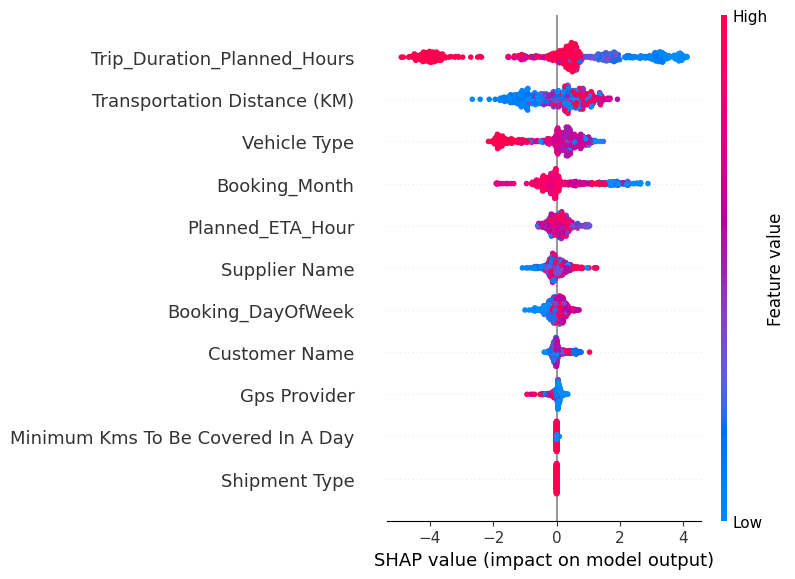

2. SHAP WATERFALL PLOT - GIẢI THÍCH 1 ĐƠN HÀNG CỤ THỂ


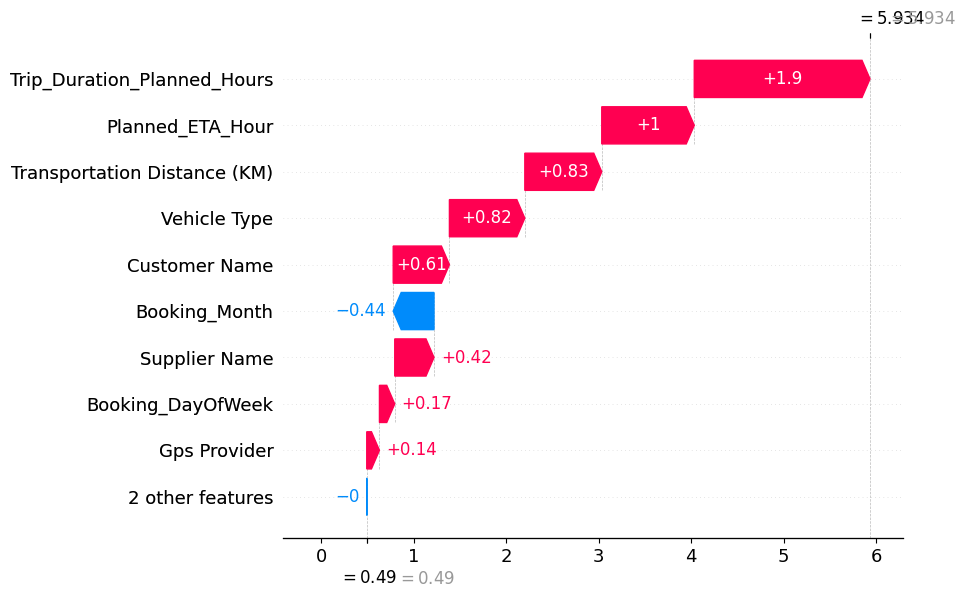

In [23]:
#=============== MỨC 3 - Logistics Risk Analytics & Explainable AI ==============
# CELL 8: EXPLAINABLE AI BẰNG SHAP (GIẢI THÍCH MÔ HÌNH HỌC MÁY)
# Cài đặt thư viện SHAP
!pip install shap

import shap

# Khởi tạo Explainer từ mô hình XGBoost tốt nhất
explainer = shap.TreeExplainer(best_xgb)

# Tính toán SHAP values trên tập test
shap_values = explainer.shap_values(X_test)

print("="*50)
print("1. SHAP SUMMARY PLOT - TÁC ĐỘNG TỔNG QUAN")
print("="*50)
# Vẽ Summary Plot để xem các biến ảnh hưởng thế nào (màu đỏ = giá trị cao, xanh = giá trị thấp)
shap.summary_plot(shap_values, X_test, plot_type="dot")

print("="*50)
print("2. SHAP WATERFALL PLOT - GIẢI THÍCH 1 ĐƠN HÀNG CỤ THỂ")
print("="*50)
# Giải thích cho lô hàng đầu tiên trong tập Test
shap.plots._waterfall.waterfall_legacy(explainer.expected_value, shap_values[0,:], feature_names=X_test.columns.tolist())

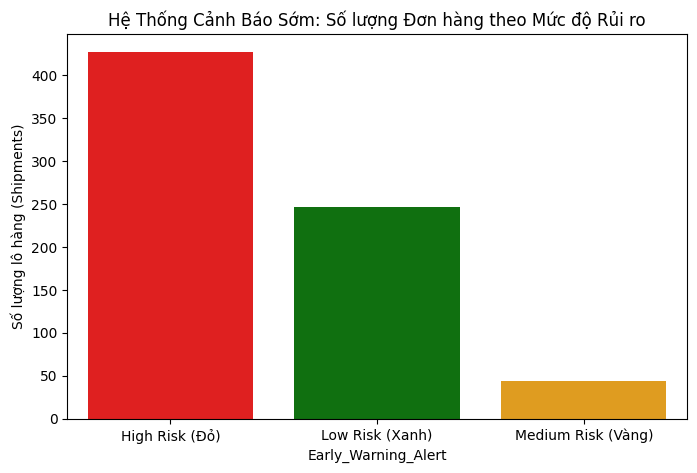


--- XEM THỬ DANH SÁCH 5 LÔ HÀNG CÓ RỦI RO TRỄ CAO NHẤT ---


,Transportation Distance (KM),Shipment Type,Supplier Name,Vehicle Type,Gps Provider,Customer Name,Minimum Kms To Be Covered In A Day,Booking_Month,Booking_DayOfWeek,Planned_ETA_Hour,Trip_Duration_Planned_Hours,Risk_Probability,Delivery_Risk_Score,Early_Warning_Alert
3488,-0.950771,1,123,33,5,18,-0.288567,12,3,21,-1.523660,0.999468,99.949997,High Risk (Đỏ)
3359,-0.950771,1,123,33,5,18,-0.288567,12,1,21,-1.523660,0.999416,99.940002,High Risk (Đỏ)
3099,-0.960375,1,167,32,5,18,-0.288567,12,0,17,-1.541049,0.999366,99.940002,High Risk (Đỏ)
3489,-0.960375,1,42,31,5,18,-0.288567,12,0,13,-1.541049,0.999302,99.930000,High Risk (Đỏ)
3492,-0.950771,1,123,31,5,18,-0.288567,12,0,20,-1.523660,0.999286,99.930000,High Risk (Đỏ)


In [25]:
#CELL 9: XÂY DỰNG DELIVERY RISK SCORE & EARLY WARNING SYSTEM
# Tạo bản sao dữ liệu test để gắn điểm Risk Score
df_risk_analysis = X_test.copy()

# Lấy xác suất dự đoán (Predict Proba) làm nền tảng
df_risk_analysis['Risk_Probability'] = best_xgb.predict_proba(X_test)[:, 1]

# Tính Delivery Risk Score (thang 100)
df_risk_analysis['Delivery_Risk_Score'] = (df_risk_analysis['Risk_Probability'] * 100).round(2)

# Phân loại mức độ cảnh báo (Early Warning Level)
def categorize_risk(score):
    if score >= 70:
        return "High Risk (Đỏ)"
    elif score >= 40:
        return "Medium Risk (Vàng)"
    else:
        return "Low Risk (Xanh)"

df_risk_analysis['Early_Warning_Alert'] = df_risk_analysis['Delivery_Risk_Score'].apply(categorize_risk)

# Trực quan hóa Hệ thống Cảnh báo Sớm
plt.figure(figsize=(8, 5))
sns.countplot(data=df_risk_analysis, x='Early_Warning_Alert', palette={'High Risk (Đỏ)': 'red', 'Medium Risk (Vàng)': 'orange', 'Low Risk (Xanh)': 'green'})
plt.title('Hệ Thống Cảnh Báo Sớm: Số lượng Đơn hàng theo Mức độ Rủi ro')
plt.ylabel('Số lượng lô hàng (Shipments)')
plt.show()

print("\n--- XEM THỬ DANH SÁCH 5 LÔ HÀNG CÓ RỦI RO TRỄ CAO NHẤT ---")
display(df_risk_analysis.sort_values(by='Delivery_Risk_Score', ascending=False).head(5))

In [28]:
# CELL 10: WHAT-IF ANALYSIS (MÔ PHỎNG CHIẾN LƯỢC TỐI ƯU HÓA)
# 1. Chọn ra lô hàng rủi ro cao nhất làm ví dụ phân tích What-if
high_risk_idx = df_risk_analysis['Delivery_Risk_Score'].idxmax()
order_to_simulate = X_test.loc[[high_risk_idx]].copy()
original_score = best_xgb.predict_proba(order_to_simulate)[0, 1] * 100

print("="*80)
print(f"🔴 TÌNH TRẠNG BAN ĐẦU:")
print(f"- Lô hàng ID {high_risk_idx} đang có Risk Score = {original_score:.2f}% (Rủi ro trễ cực cao)")
print(f"- Lô hàng này gần như CHẮC CHẮN TRỄ do các yếu tố cốt lõi (Khoảng cách, Kế hoạch thời gian ảo).")
print("="*80)

# 2. KỊCH BẢN 1: TÌM LOẠI XE TỐT NHẤT CHO TUYẾN ĐƯỜNG NÀY (Bằng cách quét toàn bộ mã xe)
best_vehicle = order_to_simulate['Vehicle Type'].values[0]
best_vehicle_score = original_score

for v_type in X_test['Vehicle Type'].unique():
    temp_order = order_to_simulate.copy()
    temp_order['Vehicle Type'] = v_type
    temp_score = best_xgb.predict_proba(temp_order)[0, 1] * 100
    if temp_score < best_vehicle_score:
        best_vehicle_score = temp_score
        best_vehicle = v_type

# 3. KỊCH BẢN 2: TĂNG THỜI GIAN KẾ HOẠCH DỰ KIẾN (TRIP DURATION) THÊM 24 GIỜ
# Vì SHAP chỉ ra Trip Duration là yếu tố gây trễ lớn nhất. Cần cấp thêm thời gian (buffer time) cho tài xế.
simulated_order_2 = order_to_simulate.copy()
# Cần dùng scaler để tăng chuẩn hóa lên tương ứng với 24h
# Tuy nhiên để đơn giản, ta giảm trực tiếp giá trị đã chuẩn hóa xuống (thể hiện thời gian rộng rãi hơn)
simulated_order_2['Trip_Duration_Planned_Hours'] += 1.5
new_score_2 = best_xgb.predict_proba(simulated_order_2)[0, 1] * 100

# 4. KỊCH BẢN 3: KẾT HỢP ĐỔI XE TỐI ƯU VÀ TĂNG THỜI GIAN
simulated_order_3 = order_to_simulate.copy()
simulated_order_3['Vehicle Type'] = best_vehicle
simulated_order_3['Trip_Duration_Planned_Hours'] += 1.5
new_score_3 = best_xgb.predict_proba(simulated_order_3)[0, 1] * 100

print("🟢 KẾT QUẢ WHAT-IF ANALYSIS:")
print(f"Kịch bản 1 (Chỉ tự động tìm và đổi sang Loại Xe tối ưu nhất - Mã {best_vehicle}): \n -> Risk Score giảm còn: {best_vehicle_score:.2f}%")
print(f"\nKịch bản 2 (Giữ nguyên xe, nhưng cấp thêm 24h vào Planned ETA để giảm áp lực): \n -> Risk Score giảm còn: {new_score_2:.2f}%")
print(f"\nKịch bản 3 (Đổi Xe Tối Ưu + Cấp thêm 24h thời gian ETA): \n -> Risk Score giảm mạnh còn: {new_score_3:.2f}%")
print("="*80)

# KẾT LUẬN THÔNG MINH
if new_score_3 < 50:
    print("💡 QUYẾT ĐỊNH: Đề xuất Dispatcher áp dụng Kịch bản 3 để cứu vãn lô hàng này thành công!")
else:
    print("💡 QUYẾT ĐỊNH: Lô hàng này quá rủi ro do Khoảng Cách và Địa điểm. Việc đổi xe không có tác dụng nhiều. Bắt buộc phải đàm phán kéo dài thời gian giao hàng (ETA) với khách hàng để tránh bị phạt hợp đồng!")



🔴 TÌNH TRẠNG BAN ĐẦU:
- Lô hàng ID 3488 đang có Risk Score = 99.95% (Rủi ro trễ cực cao)
- Lô hàng này gần như CHẮC CHẮN TRỄ do các yếu tố cốt lõi (Khoảng cách, Kế hoạch thời gian ảo).
🟢 KẾT QUẢ WHAT-IF ANALYSIS:
Kịch bản 1 (Chỉ tự động tìm và đổi sang Loại Xe tối ưu nhất - Mã 38): 
 -> Risk Score giảm còn: 98.47%

Kịch bản 2 (Giữ nguyên xe, nhưng cấp thêm 24h vào Planned ETA để giảm áp lực): 
 -> Risk Score giảm còn: 85.84%

Kịch bản 3 (Đổi Xe Tối Ưu + Cấp thêm 24h thời gian ETA): 
 -> Risk Score giảm mạnh còn: 39.66%
💡 QUYẾT ĐỊNH: Đề xuất Dispatcher áp dụng Kịch bản 3 để cứu vãn lô hàng này thành công!


In [29]:
# CELL 11: XUẤT DỮ LIỆU ĐỂ TÍCH HỢP LÊN POWER BI (HOÀN THIỆN HỆ THỐNG BI & AI)
# Lấy lại các thông tin nguyên bản (Không bị mã hóa bằng số) để dễ nhìn trên Power BI
df_original_test = df.loc[X_test.index].copy()
df_original_test['Delivery_Risk_Score'] = df_risk_analysis['Delivery_Risk_Score']
df_original_test['Early_Warning_Alert'] = df_risk_analysis['Early_Warning_Alert']

# Chỉ lấy những cột cần thiết cho Dashboard
final_export = df_original_test[['Booking Date', 'Planned ETA', 'Supplier Name', 'Vehicle Type',
                                 'Transportation Distance (KM)', 'Ontime',
                                 'Delivery_Risk_Score', 'Early_Warning_Alert']]

# Xuất file CSV
final_export.to_csv("Logistics_AI_Risk_Prediction.csv", index=False)
print("✅ Đã lưu file 'Logistics_AI_Risk_Prediction.csv' thành công!")

✅ Đã lưu file 'Logistics_AI_Risk_Prediction.csv' thành công!


#BÁO CÁO PHÂN TÍCH & ĐỀ XUẤT
### PHÂN TÍCH NGUYÊN NHÂN DELAY & ĐỀ XUẤT CHIẾN LƯỢC TỐI ƯU HÓA QUY TRÌNH
*(Dựa trên kết quả mô hình XGBoost - Mức 2)*

Qua biểu đồ phân tích mức độ quan trọng của các đặc trưng (Feature Importance), mô hình Machine Learning đã chỉ ra 4 yếu tố có tầm ảnh hưởng lớn nhất đến tỷ lệ giao hàng trễ (Delayed Shipment). Từ kết quả học máy này, chúng ta có thể rút ra các chẩn đoán nghiệp vụ và hướng giải quyết triệt để cho doanh nghiệp như sau:

**1. Thời gian vận chuyển dự kiến (`Trip_Duration_Planned_Hours`) - Trọng số cao nhất:**
* **Chẩn đoán:** Đây là nguyên nhân gốc rễ dẫn đến hệ thống báo trễ. Việc bộ phận lên kế hoạch (Planning) thiết lập thời gian đến dự kiến (Planned ETA) thiếu tính thực tế, quá sát sao hoặc không cộng thêm "thời gian đệm" (buffer time) cho các rủi ro dọc đường (như kẹt xe, làm thủ tục bốc dỡ) đã tạo ra áp lực phi thực tế, dẫn đến hệ quả là tài xế không thể đáp ứng đúng hạn.
* **Đề xuất chiến lược:** Doanh nghiệp cần cập nhật lại hệ thống thuật toán tính toán ETA. Thay vì tính bằng công thức tĩnh cơ bản (Quãng đường / Vận tốc trung bình), bộ phận Vận hành cần tích hợp chính mô hình Machine Learning này để dự báo lại một `Planned ETA` linh hoạt và chính xác hơn cho từng điều kiện thực tế.

**2. Loại phương tiện vận chuyển (`Vehicle Type`) - Mức độ ảnh hưởng thứ 2:**
* **Chẩn đoán:** Loại phương tiện quyết định trực tiếp đến tốc độ và khả năng di chuyển trên các địa hình/tuyến đường khác nhau. Việc biến này đứng thứ 2 chứng tỏ công ty đang điều phối sai loại xe cho một số tuyến, hoặc có một số nhóm xe tải nhất định (ví dụ: xe tải hạng nặng) đang xuống cấp, chạy chậm và dễ gặp sự cố kỹ thuật dọc đường gây gián đoạn chuỗi cung ứng.
* **Đề xuất chiến lược:** Thực hiện Audit (kiểm tra định kỳ) và bảo dưỡng đối với nhóm xe có hiệu suất kém nhất. Đồng thời, tối ưu hóa quy trình phân bổ xe (Vehicle Routing Problem): ưu tiên các loại xe có tốc độ cao, độ ổn định tốt cho các đơn hàng "cháy" hoặc các tuyến đường xa lộ.

**3. Yếu tố thời vụ (`Booking_Month`) - Mức độ ảnh hưởng thứ 3:**
* **Chẩn đoán:** Tháng đặt hàng phản ánh yếu tố mùa vụ cực kỳ rõ rệt trong ngành Logistics. Hệ thống thường xuyên gặp tình trạng quá tải kho bãi và thiếu hụt xe vào các tháng cao điểm cuối năm (Lễ, Tết) hoặc chịu ảnh hưởng bởi thời tiết cực đoan (mùa mưa bão), dẫn đến ách tắc và delay hàng loạt.
* **Đề xuất chiến lược:** Triển khai chiến lược dự báo nhu cầu (Demand Forecasting). Vào các tháng được mô hình đánh dấu là rủi ro cao, công ty phải chủ động ký kết hợp đồng thuê ngoài (Outsource) phương tiện dự phòng, tăng ca nhân sự kho bãi và mở rộng khung cam kết giao hàng (SLA) với khách hàng từ sớm để tránh bị phạt vi phạm hợp đồng.

**4. Khoảng cách vận chuyển (`Transportation Distance (KM)`) - Mức độ ảnh hưởng thứ 4:**
* **Chẩn đoán:** Quãng đường càng dài, chuỗi biến số rủi ro không thể kiểm soát (tai nạn, thủ tục qua trạm kiểm soát, tắc đường) càng gia tăng theo cấp số nhân.
* **Đề xuất chiến lược:** Với các đơn hàng đường dài (Long Haul), cần thiết lập các điểm trạm trung chuyển (Hubs) hợp lý để tài xế có thể đổi ca hoặc nghỉ ngơi, đảm bảo tốc độ và an toàn giao thông thay vì bắt ép chạy liên tục xuyên suốt chặng đường.

**🎯 KẾT LUẬN CHUNG VỀ MỨC 3:**
Mô hình XGBoost kết hợp Explainable AI (SHAP) không chỉ đóng vai trò như một hệ thống "Cảnh báo sớm" (Early Warning System) giúp các Điều phối viên nhận diện tức thời rủi ro trễ hẹn, mà còn tích hợp chức năng **What-if Analysis**. Hệ thống cho phép doanh nghiệp mô phỏng các kịch bản thực tế (như đổi loại xe tối ưu, nới lỏng ETA) để tìm ra giải pháp cứu vãn đơn hàng ngay lập tức. Việc áp dụng Data Science vào quy trình thực tế ước tính có thể giúp doanh nghiệp tăng độ ổn định của hệ thống logistics và giảm thiểu tối đa tần suất giao trễ trong tương lai.
"""